In [46]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv
/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv


# INTRODUCTION


Loan Prediction ek Machine Learning classification problem hai jisme hum predict karte hain ki applicant ka loan approve hoga ya nahi, based on features jaise income, education, loan amount, credit history etc.

# Objective

Understand the dataset or
Perform data cleaning
Analyze important features,
Build a prediction model and
Evaluate model performance

**Import Required Libraries**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

****Load the Dataset****

Loading the dataset is the process of importing data into Python so that it can be explored, analyzed, and used for machine learning. In this project, we use the Pandas library to read the CSV file.

In [48]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


****Understanding the Dataset****

Understanding the dataset is the first step of data analysis. It helps us know the number of rows, columns, data types, and overall structure of the dataset before performing any analysis.

In [49]:

df.shape


(614, 13)

In [50]:

df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [51]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [52]:

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Statistical Summary of the Dataset

A statistical summary provides important numerical information about the dataset such as count, mean, standard deviation, minimum value, maximum value, and quartiles. It helps in understanding the distribution of numerical features.

In [53]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Checking Missing Values

Missing values are empty or null entries in the dataset. They can affect the performance of a machine learning model, so they should be identified and handled properly.

In [54]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Checking Duplicate Records

Duplicate records are repeated rows in a dataset. Removing duplicate records improves the quality and accuracy of data analysis.

In [55]:
df.duplicated().sum()

np.int64(0)

# Displaying Data Types

Data types define the kind of values stored in each column, such as integers, floating-point numbers, or text (objects). Knowing data types helps in selecting the correct preprocessing techniques.

In [56]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

# Data Visualization

Data Visualization is the graphical representation of data using charts and graphs. It helps in identifying patterns, trends, and relationships in the dataset.

# Loan Status Distribution

This chart shows the number of approved and rejected loan applications. It helps us understand the balance of the target variable.

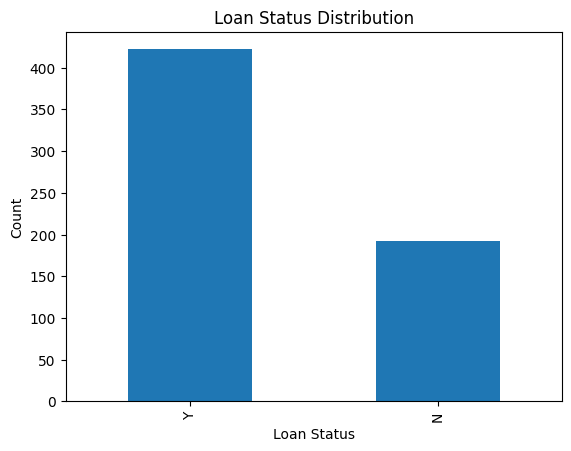

In [57]:
import matplotlib.pyplot as plt

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

**Observation****

The chart shows the number of approved (Y) and rejected (N) loan applications.

# Gender Distribution

This graph shows the distribution of male and female applicants in the dataset.

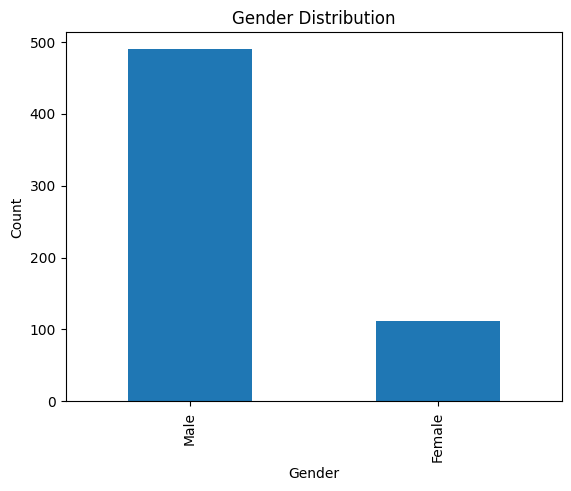

In [58]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**Observation**

The dataset contains both male and female applicants, with one category having a higher count.

# Education Distribution

This graph represents the educational qualification of loan applicants.

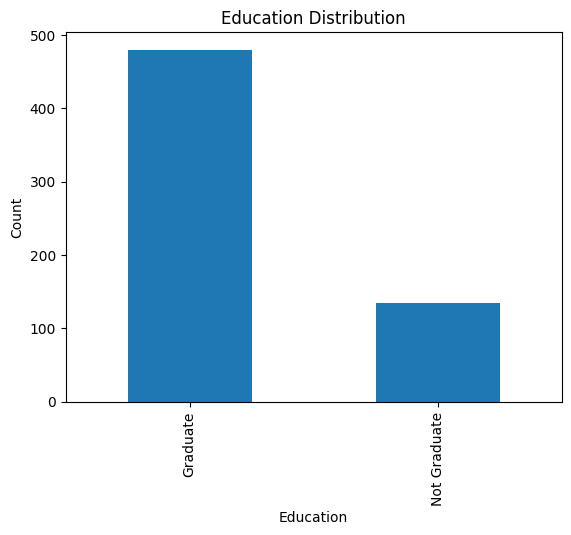

In [59]:
df["Education"].value_counts().plot(kind="bar")

plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

**Observation**

The graph shows the number of graduates and non-graduates in the dataset.

# Applicant Income Distribution

Applicant Income Distribution shows how the income of loan applicants is spread across the dataset. It helps identify the most common income range and detect outliers.

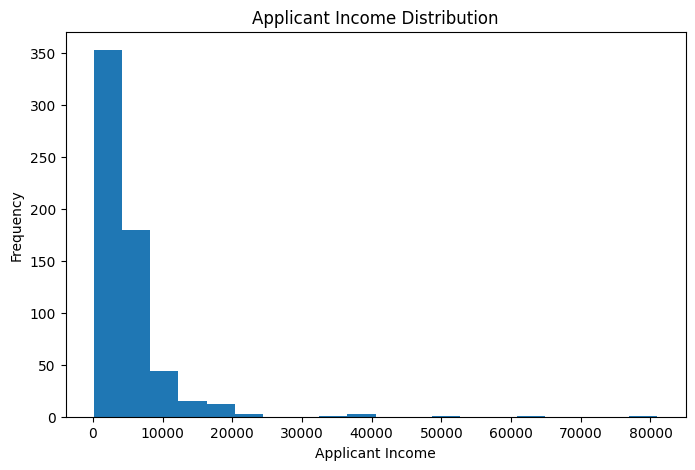

In [60]:
plt.figure(figsize=(8,5))
df["ApplicantIncome"].plot(kind="hist", bins=20)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

**Observation**

Most applicants fall within a specific income range, while a few applicants have very high incomes, indicating the presence of outliers.

# Loan Amount Distribution

This graph shows how loan amounts are distributed among applicants.

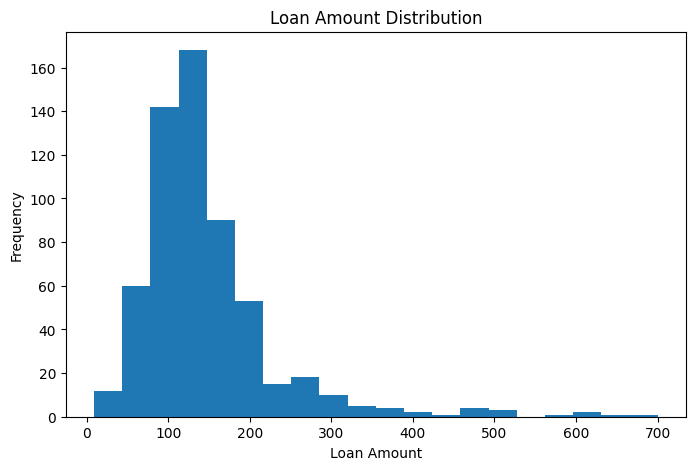

In [61]:
plt.figure(figsize=(8,5))
df["LoanAmount"].plot(kind="hist", bins=20)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

**Observation**

Most applicants applied for medium loan amounts, while only a few requested very high loan amounts.

# Credit History Distribution

Credit history indicates whether an applicant has a good repayment record. It is one of the most important factors in loan approval. 

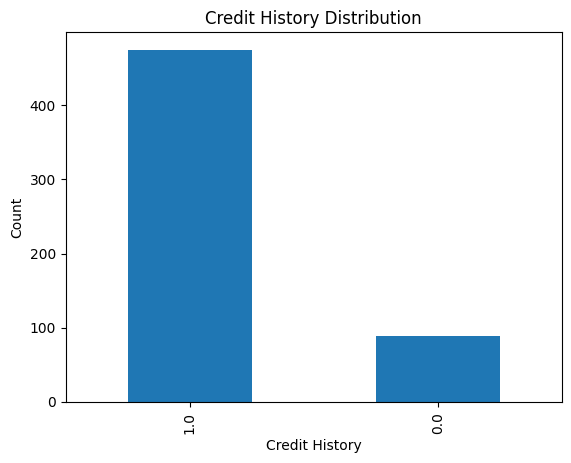

In [62]:
df["Credit_History"].value_counts().plot(kind="bar")

plt.title("Credit History Distribution")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.show()

**Observation**

Applicants with a positive credit history are more common and are generally more likely to receive loan approval.

# Correlation Heatmap

A correlation heatmap shows the relationship between numerical variables. Correlation values range from -1 to +1, where values closer to +1 indicate a strong positive relationship and values closer to -1 indicate a strong negative relationship.

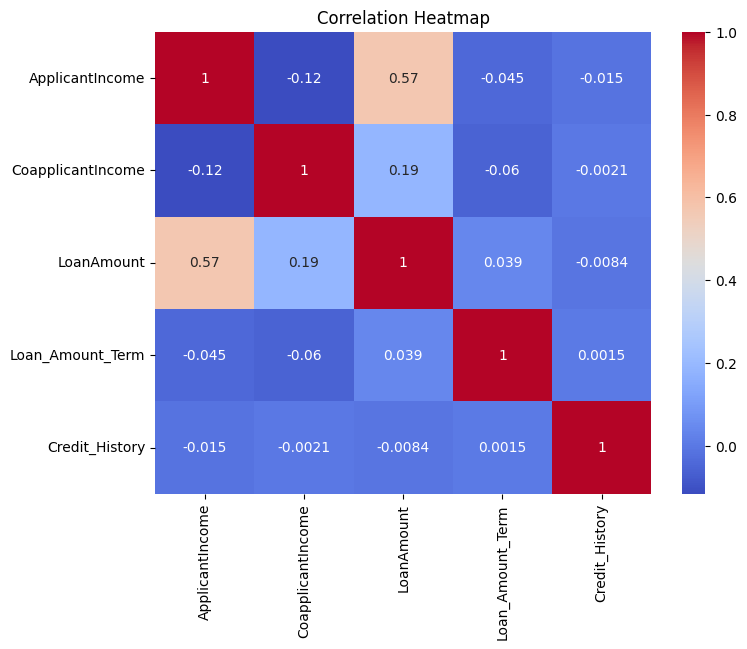

In [63]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=["number"]).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

**Observation**

The heatmap shows the correlation among numerical features. Highly correlated features may influence model performance.

# Data Preprocessing

Data preprocessing is the process of cleaning and preparing raw data before training a machine learning model. It improves data quality and helps the model make better predictions. 

**Fill Missing Values**

In [64]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Encoding Categorical Data

Machine learning algorithms work with numerical data. Encoding converts categorical values such as "Male", "Female", "Yes", and "No" into numbers.

In [65]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# Splitting the Dataset

Dataset splitting is the process of dividing the data into two parts:
Training Data: Used to train the machine learning model.
Testing Data: Used to evaluate the model's performance on unseen data.

In [66]:
from sklearn.model_selection import train_test_split

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 12)
Testing data: (123, 12)


# Building the Logistic Regression Model

Logistic Regression is a classification algorithm used to predict categorical outcomes. In this project, it predicts whether a loan application will be approved or rejected.

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000, solver="liblinear")

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, solver='liblinear')

# Model Prediction and Accuracy

After training, the model predicts the loan status for the test data. Accuracy tells us how many predictions are correct.

In [68]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 78.86 %


# Conclusion

In this project, we analyzed the Loan Prediction dataset, handled missing values, converted categorical data into numerical format, visualized important information, and built a Logistic Regression model. The model was evaluated using accuracy and can be used to predict whether a loan application is likely to be approved.